In [1]:
!pip install herbie-data xarray metpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.2/118.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.6/91.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 99.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 22.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take 

In [2]:
!pwd

/content


In [3]:
import herbie

 ╭─▌▌Herbie─────────────────────────────────────────────╮
 │ INFO: Created a default config file.                 │
 │ You may view/edit Herbie's configuration here:       │
 │          /root/.config/herbie/config.toml            │
 ╰──────────────────────────────────────────────────────╯



In [13]:
"""
Download HRRR data for a specific point and save it as a NetCDF file suitable for MetPy Skew-T plots.
This script pulls temperature, dewpoint, wind components, and geopotential height at multiple
isobaric levels, along with surface and near-surface variables.
"""

import os
import datetime

import pandas as pd

import xarray as xr
from herbie.fast import FastHerbie

# --- Configuration ---
# Coordinates for the Skew-T profile
# QUERY_LAT_LON = (37.406086, -122.175629) # Stanford University (Example)
# QUERY_LAT_LON = (38.359550, -105.733399)   # CO Spot Forecast Example
QUERY_LAT_LON = (38.573363,-122.691302)   # Pepperwood Forecast Example
# QUERY_LAT_LON = (33.75, -83.25)   # Atlanta C-180 Rx

# Time range and forecast lead time
# Using a single time for a specific sounding, or a range for a time series of soundings
# DATETIME_START = "2026-03-27T16:00:00"
# DATETIME_END = "2026-03-27T16:00:00"
# DATETIME_START = "2025-10-23T19:00:00"
# DATETIME_END = "2025-10-23T19:00:00"
DATETIME_START = "2025-10-24T00:00:00"
DATETIME_END = "2025-10-24T00:00:00"
# DATETIME_START = "2026-04-09T19:00:00"
# DATETIME_END = "2026-04-09T19:00:00"
INTERVAL = 1 # hours
FORECAST_HOURS = 0 # Analysis (F00) is typical for soundings

# Output Directory
NC_SAVE_DIR = "/content/hrrr_netcdf/"
os.makedirs(NC_SAVE_DIR, exist_ok=True)

# Variables for Skew-T:
# - Profile: TMP, DPT, UGRD, VGRD, HGT at isobaric levels (e.g., 1000 mb, 850 mb, etc.)
# - Surface/Near-surface:
#   - TMP:surface, PRES:surface, HGT:surface (topography)
#   - TMP:2 m above ground, DPT:2 m above ground
#   - UGRD:10 m above ground, VGRD:10 m above ground
# This regex captures all of the above.
# Note: HRRR "sfc" product has a subset of pressure levels.
# For a high-resolution profile, "prs" product is recommended.
# Use non-capturing groups (?:...) to avoid pandas UserWarning.
SKEWT_VARS_RE = r":(?:TMP|DPT|UGRD|VGRD|HGT|PRES):(?:(?:[0-9]+ mb)|(?:surface)|(?:[2,10] m above ground))"

def pull_hrrr_skewt_data():
    """
    Initialize FastHerbie and download the specified variables.
    """
    dates = pd.date_range(DATETIME_START, DATETIME_END, freq=f"{INTERVAL}h")
    fxx = [FORECAST_HOURS]

    print("--- FastHerbie Setup ---")
    print(f"Dates: {dates.strftime('%Y-%m-%d %H:%M').tolist()}")
    print(f"Forecast Hours: {fxx}")

    print(f"Searching for variables with regex: {SKEWT_VARS_RE}")

    # Initialize FastHerbie
    # Using product="prs" for better vertical resolution
    print("Attempting to use HRRR 'prs' product for full vertical resolution...")
    fh = FastHerbie(dates, model="hrrr", fxx=fxx, product="prs") # pyright: ignore[reportArgumentType]

    # fh.xarray() can return a list of datasets if variables are incompatible
    ds_out = fh.xarray(SKEWT_VARS_RE, remove_grib=False)

    if isinstance(ds_out, list):
        print(f"fh.xarray returned a list of {len(ds_out)} datasets. Merging...")

        # Merge datasets, allowing for different variables and coordinates
        ds = xr.merge(ds_out, compat="override")
    else:
        ds = ds_out

    print("\nDataset successfully loaded into memory.")
    return ds


def extract_point(ds):
    """
    Extract data at the specific Query Lat/Lon and save to NetCDF.
    """
    print("\n--- Extracting Point Data ---")
    print(f"Target Lat/Lon: {QUERY_LAT_LON}")

    points_df = pd.DataFrame({
        "latitude": [QUERY_LAT_LON[0]],
        "longitude": [QUERY_LAT_LON[1]]
    })

    # Use herbie's pick_points accessor
    ds_point = ds.herbie.pick_points(points_df, method="nearest")
    return ds_point


def save_point_to_netcdf(ds_point):
    """
    Save the point dataset to a NetCDF file.
    """
    print("\n--- Saving Point Data to NetCDF ---")
    # Format filename
    start_str = datetime.datetime.strptime(DATETIME_START, "%Y-%m-%dT%H:%M:%S").strftime("%Y%m%d_%H%M")
    lat_str = f"{QUERY_LAT_LON[0]:.3f}".replace(".", "p")
    lon_str = f"{QUERY_LAT_LON[1]:.3f}".replace(".", "p")

    filename = f"hrrr_skewt_{lat_str}_{lon_str}_{start_str}.nc"
    save_path = os.path.join(NC_SAVE_DIR, filename)

    print(f"Saving point dataset to: {save_path}")
    ds_point.to_netcdf(save_path)
    print("Save complete.")
    return save_path

if __name__ == "__main__":
    ds = pull_hrrr_skewt_data()
    ds_point = extract_point(ds)

    print(f"\nExtracted point dataset:\n{ds_point}")

    save_path = save_point_to_netcdf(ds_point)
    print(f"\nSuccess! Data is ready for SkewT at: {save_path}\n\n")


--- FastHerbie Setup ---
Dates: ['2025-10-24 00:00']
Forecast Hours: [0]
Searching for variables with regex: :(?:TMP|DPT|UGRD|VGRD|HGT|PRES):(?:(?:[0-9]+ mb)|(?:surface)|(?:[2,10] m above ground))
Attempting to use HRRR 'prs' product for full vertical resolution...


/usr/local/lib/python3.12/dist-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/usr/local/lib/python3.12/dist-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/usr/local/lib/python3.12/dist-packages/cfgrib

fh.xarray returned a list of 3 datasets. Merging...

Dataset successfully loaded into memory.

--- Extracting Point Data ---
Target Lat/Lon: (38.573363, -122.691302)

Extracted point dataset:
<xarray.Dataset> Size: 1kB
Dimensions:              (point: 1, isobaricInhPa: 39)
Coordinates:
  * isobaricInhPa        (isobaricInhPa) float64 312B 1e+03 975.0 ... 75.0 50.0
    time                 datetime64[ns] 8B 2025-10-24
    step                 timedelta64[ns] 8B 00:00:00
    heightAboveGround    float64 8B 2.0
    latitude             (point) float64 8B 38.57
    longitude            (point) float64 8B 237.3
    valid_time           datetime64[ns] 8B 2025-10-24
    gribfile_projection  object 8B None
    surface              float64 8B 0.0
    point_grid_distance  (point) float64 8B 0.7798
    point_latitude       (point) float64 8B 38.57
    point_longitude      (point) float64 8B -122.7
Dimensions without coordinates: point
Data variables:
    t2m                  (point) float32 4B 29


Loading data from /content/hrrr_netcdf/hrrr_skewt_38p573_-122p691_20251024_0000.nc...
Processing profile and surface data...
<xarray.Dataset> Size: 1kB
Dimensions:              (point: 1, isobaricInhPa: 39)
Coordinates:
  * isobaricInhPa        (isobaricInhPa) float64 312B 1e+03 975.0 ... 75.0 50.0
    time                 datetime64[ns] 8B ...
    step                 timedelta64[ns] 8B ...
    heightAboveGround    float64 8B ...
    latitude             (point) float64 8B ...
    longitude            (point) float64 8B ...
    valid_time           datetime64[ns] 8B ...
    gribfile_projection  float64 8B ...
    surface              float64 8B ...
    point_grid_distance  (point) float64 8B ...
    point_latitude       (point) float64 8B ...
    point_longitude      (point) float64 8B ...
Dimensions without coordinates: point
Data variables:
    t2m                  (point) float32 4B ...
    d2m                  (point) float32 4B ...
    t                    (isobaricInhPa, point)

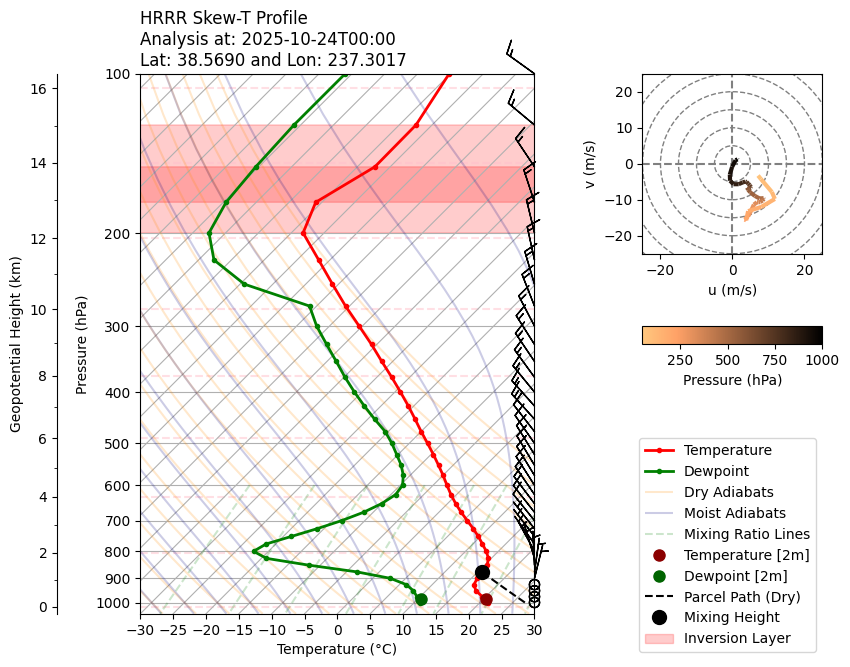

In [14]:
"""
Generate a Skew-T Log-P plot using MetPy from HRRR data saved in a NetCDF file.
"""

import os
from dataclasses import dataclass
from typing import Any, Tuple

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import NullFormatter, MultipleLocator, FuncFormatter

import xarray as xr

import metpy.calc as mpcalc
import metpy.interpolate as mpinterpolate
import metpy.constants as mpconst
from metpy.plots import SkewT, Hodograph
from metpy.units import units

# --- Configuration ---
# NC_FILE_PATH = "/glade/derecho/scratch/dneamati/hrrr_netcdf/hrrr_skewt_37p406_-122p176_20260415_0000.nc"
# PLOT_SAVE_DIR = "/glade/u/home/dneamati/HRRR/plots/skewt/"

# NC_FILE_PATH = "/content/hrrr_netcdf/hrrr_skewt_38p360_-105p733_20260327_1600.nc"
# NC_FILE_PATH = "/content/hrrr_netcdf/hrrr_skewt_38p573_-122p691_20251023_1900.nc"
NC_FILE_PATH = "/content/hrrr_netcdf/hrrr_skewt_38p573_-122p691_20251024_0000.nc"
# NC_FILE_PATH = "/content/hrrr_netcdf/hrrr_skewt_33p750_-83p250_20260409_1900.nc"
PLOT_SAVE_DIR = "/content/skewt_spot/"


@dataclass
class SkewTPlotSettings:
    """Configuration class for Skew-T and Hodograph plotting."""

    # Subplot placements [left, bottom, width, height]
    skewt_rect: Tuple[float, float, float, float] = (0.1, 0.1, 0.48, 0.6)
    hodo_rect: Tuple[float, float, float, float] = (0.7, 0.5, 0.2, 0.2)
    hodo_cb_rect: Tuple[float, float, float, float] = (0.7, 0.4, 0.2, 0.02)

    # Plot limits and parameters (using Any to avoid Pyright issues with units.Quantity)
    p_min: Any = 100 * units.hPa
    p_max: Any = 1050 * units.hPa
    t_min: Any = -30 * units.degC
    t_max: Any = 30 * units.degC

    # p_min: Any = 650 * units.hPa
    # p_max: Any = 1050 * units.hPa
    # t_min: Any = 6 * units.degC
    # t_max: Any = 22 * units.degC

    # p_min: Any = 10 * units.hPa
    # p_max: Any = 1400 * units.hPa
    # t_min: Any = -60 * units.degC
    # t_max: Any = 50 * units.degC

    wind_max: Any = 25 * units.meters / units.second
    skew_rotation: int = 45
    figsize: Tuple[int, int] = (9, 9)

    # Barb plotting
    barbs_interval: int = 1  # Plot every nth barb to reduce clutter
    # Horizontal offset for barbs (as a fraction of x-axis range)
    # recommend: 0.05 when height axis on right, otherwise 0
    bard_offset: float = 0

    # Adiabat styles and alphas
    adiabat_alpha: float = 0.2
    adiabat_linestyle: str = "-"

    dry_adiabat_color: str = "darkorange"
    moist_adiabat_color: str = "navy"

    mixing_ratio_alpha: float = 0.2
    mixing_ratio_linestyle: str = ":"

    # Axes resolution for plotting lines
    temp_resolution: int = 5
    p_resolution: int = 100

    # temp_resolution: int = 2
    # p_resolution: int = 50

    # temp_resolution: int = 10
    # p_resolution: int = 100

    # Surface markers
    surface_marker: str = "o"
    surface_marker_size: int = 8
    surface_marker_color_t: str = "darkred"
    surface_marker_color_td: str = "darkgreen"

    # Height axis
    show_height_axis: bool = True

    height_units: str = "km"  # 'm' or 'km'
    height_tick_interval: int = 2  # in meters or km

    # height_units: str = "m"  # 'm' or 'km'
    # height_tick_interval: int = 100  # in meters or km

    height_axis_location: str = "left"  # 'left' or 'right'
    height_axis_left_offset: int = 60  # Only used if height_axis_location is 'left'
    extrapolate_height_axis: bool = True
    height_type: str = "geopotential"  # 'msl' (geometric height) or 'geopotential'

    # Mixing Height calculation
    mixing_height_temp_offset: float = 5.0 * units.delta_degC  # (offset from surface temperature)

    # Legend
    legend_loc: str = "upper left"
    legend_outside: bool = True  # If True, place in bottom right of figure
    legend_anchor: tuple = (0.9, 0.05)  # For outside legend placement

    # Saving
    save_filename: str = "hrrr_skewt_hgt_metpy_lapse_2.png"

    # Debugging
    show_debug_rects: bool = False


def load_data(file_path):
    """Load the NetCDF dataset."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Data file not found at {file_path}")
    print(f"Loading data from {file_path}...")
    return xr.open_dataset(file_path)


def process_profile_data(ds, settings=None):
    """
    Extract profile and surface variables, attach units, and sort profile by pressure.
    """
    print("Processing profile and surface data...")

    print(ds)

    # Identify the vertical dimension
    if "isobaricInhPa" in ds.coords:
        p = ds["isobaricInhPa"].values * units.hPa
    else:
        # Fallback: search for isobaric coordinate
        p_coords = [c for c in ds.coords if "isobaric" in c]
        if not p_coords:
            raise KeyError("No isobaric pressure coordinate found in dataset.")
        print(f"Fallback: Using coordinate '{p_coords[0]}' for pressure levels.")
        p = ds[p_coords[0]].values * units.hPa

    # Extract profile variables and attach units
    # Ensure 1D arrays by squeezing (handles the 'point' dimension if it exists)
    T = np.atleast_1d(ds["t"].values.squeeze()) * units.degK
    Td = np.atleast_1d(ds["dpt"].values.squeeze()) * units.degK
    u = np.atleast_1d(ds["u"].values.squeeze()) * units.meters / units.second
    v = np.atleast_1d(ds["v"].values.squeeze()) * units.meters / units.second
    z_geopotential_height = np.atleast_1d(ds["gh"].values.squeeze()) * units.meters

    # Extract surface variables
    t2m = ds["t2m"].values.item() * units.degK
    d2m = ds["d2m"].values.item() * units.degK
    sp = ds["sp"].values.item() * units.Pa
    sp = sp.to(units.hPa)
    orog = ds["orog"].values.item() * units.meters

    print(
        f"\nSurface pressure: {sp:.2f}, "
        + f"2m temperature: {t2m:.2f}, "
        + f"2m dewpoint: {d2m:.2f}, "
        + f"Orography: {orog:.2f}\n"
    )

    # Convert geopotential height to MSL altitude if requested
    if settings and settings.height_type == "msl":
        print("Converting Geopotential Height to MSL Altitude...")
        geopotential = z_geopotential_height * mpconst.g
        z = mpcalc.geopotential_to_height(geopotential)
    else:
        z = z_geopotential_height

    # Sort profile by pressure (surface to top, i.e., decreasing pressure)
    idx = np.argsort(p)[::-1]
    p = p[idx]
    T = T[idx]
    Td = Td[idx]
    u = u[idx]
    v = v[idx]
    z = z[idx]

    # Gather metadata for plotting
    metadata = {
        "lat": ds.latitude.values.item(),
        "lon": ds.longitude.values.item(),
        "valid_time": ds.valid_time.values,
        "surface": {"t2m": t2m, "d2m": d2m, "sp": sp},
        "profile_z": z,
    }
    # If valid_time is an array (due to FastHerbie formatting), take the first element
    if isinstance(metadata["valid_time"], np.ndarray):
        metadata["valid_time"] = metadata["valid_time"][0]

    return p, T, Td, u, v, metadata


def add_debug_patches(fig, settings):
    """Add colored rectangles to debug subplot placement."""
    print("Adding debug patches...")
    fig.patches.append(
        patches.Rectangle(
            (settings.skewt_rect[0], settings.skewt_rect[1]),
            settings.skewt_rect[2],
            settings.skewt_rect[3],
            transform=fig.transFigure,
            edgecolor="r",
            facecolor="none",
            zorder=10,
            linewidth=2,
        )
    )
    fig.patches.append(
        patches.Rectangle(
            (settings.hodo_rect[0], settings.hodo_rect[1]),
            settings.hodo_rect[2],
            settings.hodo_rect[3],
            transform=fig.transFigure,
            edgecolor="b",
            facecolor="none",
            zorder=10,
            linewidth=2,
        )
    )
    fig.patches.append(
        patches.Rectangle(
            (settings.hodo_cb_rect[0], settings.hodo_cb_rect[1]),
            settings.hodo_cb_rect[2],
            settings.hodo_cb_rect[3],
            transform=fig.transFigure,
            edgecolor="g",
            facecolor="none",
            zorder=10,
            linewidth=2,
        )
    )


def calculate_inversion_layer(p, T, z):
    """Identify inversion layer where temperature increases with height."""
    print("Calculating inversion layers...")
    # # Calculate the temperature difference between levels
    # dT = np.diff(T)
    # dp = np.diff(p)

    # # An inversion occurs where dT/dp < 0 (temperature increases as pressure decreases)
    # # True is inversion, False is normal lapse
    # inversion_mask = dT / dp < 0

    dT_by_dp = mpcalc.first_derivative(T, x=p)
    inversion_mask = dT_by_dp < 0

    inversion_layers = {
        "inversion_pressure": p[inversion_mask],
        "inversion_temperature": T[inversion_mask],
        "inversion_height": z[inversion_mask]
    }
    return inversion_layers


def report_inversion_layer(inversion_layers, banner_num=50):
    """Print the inversion layer results in a readable format."""
    if len(inversion_layers["inversion_pressure"]) == 0:
        print("No inversion layers detected.")
        return

    print("\n" + "="*banner_num)
    print("       INVERSION LAYER REPORT")
    print("="*banner_num)
    for i, (p_inv, T_inv, z_inv) in enumerate(zip(
        inversion_layers["inversion_pressure"],
        inversion_layers["inversion_temperature"],
        inversion_layers["inversion_height"]
    )):
        print(f"Inversion {i+1}:")
        print(f"  Pressure: {p_inv: .2f}")
        print(f"  Temperature: {T_inv.to('degC'): .2f}")
        print(f"  Height: {z_inv: .2f}")
    print("="*banner_num + "\n")

def draw_inversion_layer(skew, p, inversion_layers, settings):
    """Plot the inversion layers on the Skew-T as a band of red behind
    everything else from the layer below to the layer above (if possible)."""
    if len(inversion_layers["inversion_pressure"]) == 0:
        return

    # Only add the label once
    label_added = False

    print("Plotting inversion layers...")
    for p_inv in inversion_layers["inversion_pressure"]:
        print(f"Plotting inversion layer at pressure: {p_inv:.2f}...")
        # Find the pressure levels immediately above and below the inversion layer
        p_below = p[p < p_inv]
        p_above = p[p > p_inv]

        if len(p_below) == 0 or len(p_above) == 0:
            continue  # Skip if we can't find both sides

        p_lower = p_below[0]
        p_upper = p_above[-1]

        print(f"  Lower pressure: {p_lower:.2f}, Upper pressure: {p_upper:.2f}")

        # Plot a filled rectangle between these two pressure levels across the full temperature range
        skew.ax.fill_betweenx(
            [p_lower, p_upper],
            -1000,
            1000,
            color="red",
            alpha=0.2,
            zorder=0,
            label="Inversion Layer" if not label_added else None
        )
        label_added = True


def calculate_mixing_level(p, T, u, v, z, metadata, offset=5.0 * units.delta_degC):
    """
    Calculate the mixing height using the parcel method (dry adiabat intersection).

    Parameters:
    p, T, u, v: Profile arrays (with units)
    z: Height profile array (with units)
    metadata: Metadata dictionary containing surface conditions
    offset: Temperature offset to add to surface temperature (default 5 degC)

    Returns:
    Dictionary with mixing level parameters or None if no intersection is found.
    """
    print(f"Calculating mixing height with temperature offset: {offset}...")

    surf = metadata["surface"]
    sp = surf["sp"]
    t2m = surf["t2m"]

    # 1. Parcel profile (dry adiabat only)
    # Following the dry adiabat from (sp, t2m + offset) up to the levels in p
    # p_full = np.concatenate(([sp], p))
    Tp = mpcalc.dry_lapse(p, t2m + offset, reference_pressure=sp)

    # 2. Find intersection with environmental temperature profile T
    # Use log_x=True because pressure is logarithmic in the atmosphere
    # T_full = np.concatenate((T[0:1], T))
    intersect_pt = mpcalc.find_intersections(p, Tp, T, log_x=True)
    # intersect_pt is a tuple of (pressure_list, temperature_list)

    if len(intersect_pt) == 0:
        print("No mixing height intersection found within the profile.")
        return None

    # Take the first intersection above the surface (may or may not be
    # the highest pressure). Since p is sorted from low altitude (high P) to
    # high altitude (low P), find_intersections returns them in that order.
    mixing_p = intersect_pt[0][0]
    if len(intersect_pt[0]) > 1:
        print(f"Multiple intersections found at pressures: {intersect_pt[0]}")
        for p_val, _ in intersect_pt:
            if p_val > sp:
                mixing_p = p_val
                break

    # 3. Interpolate height, temperature, and wind at the intersection pressure
    mixing_z = mpinterpolate.interpolate_1d(mixing_p, p, z)
    mixing_t = mpinterpolate.interpolate_1d(mixing_p, p, T)
    mixing_u = mpinterpolate.interpolate_1d(mixing_p, p, u)
    mixing_v = mpinterpolate.interpolate_1d(mixing_p, p, v)

    mixing_speed = mpcalc.wind_speed(mixing_u, mixing_v)
    mixing_direction = mpcalc.wind_direction(mixing_u, mixing_v)

    return {
        "offset": offset,
        "pressure": mixing_p,
        "height": mixing_z[0],
        "temperature": mixing_t[0],
        "u": mixing_u[0],
        "v": mixing_v[0],
        "speed": mixing_speed[0],
        "direction": mixing_direction[0]
    }


def report_mixing_level(results, banner_num=50):
    """Print the mixing level results in a readable format."""
    if results is None:
        print("Mixing height could not be determined.")
        return

    # Note the ': .2f' formatting with the space to allow negative sign space
    print("\n" + "="*banner_num)
    print("       MIXING HEIGHT REPORT")
    print("="*banner_num)
    print(f"Parcel T_Offset: {results['offset']: .2f}")
    print(f"Pressure:        {results['pressure']: .2f}")
    print(f"Height:          {results['height']: .2f}")
    print(f"Temperature:     {results['temperature'].to('degC'): .2f}")
    print(f"Wind Speed:      {results['speed']: .2f}")
    print(f"Wind U:          {results['u']: .2f}")
    print(f"Wind V:          {results['v']: .2f}")
    print(f"Wind Direction:  {results['direction']: .1f}")
    print("="*banner_num + "\n")


def draw_mixing_height(skew, p, metadata, results):
    """Draw the parcel trajectory and mark the mixing height."""
    if results is None:
        return

    print("Drawing mixing height and parcel trajectory...")
    surf = metadata["surface"]

    # Calculate the full parcel trajectory (dry adiabat)
    # Start from surface pressure and surface temperature + offset
    if p[0] < surf["sp"]:
        p_full =np.concatenate(([surf["sp"]], p))
    else:
        p_full = p
    parcel_path = mpcalc.dry_lapse(p_full, surf["t2m"] + results["offset"],
                                   reference_pressure=surf["sp"])

    # Plot the parcel path (only up to the mixing height pressure)
    # Mask, but round up to the next pressure level to ensure we
    # include the mixing height point if it falls between levels
    mask_higher_p = p_full >= results["pressure"] # True if at or below mixing
    lowest_avail_p_idx = np.argmin(p_full[mask_higher_p])
    if lowest_avail_p_idx < len(p_full) - 1:
        next_p = p_full[lowest_avail_p_idx + 1]
        mask = p_full >= next_p
    else:
        mask = mask_higher_p

    skew.plot(p_full[mask], parcel_path[mask].to("degC"), color="black",
              linestyle="--", linewidth=1.5, label="Parcel Path (Dry)")

    # Mark the mixing height intersection
    skew.plot(results["pressure"], results["temperature"].to("degC"),
              marker="o", markersize=10, color="black",
              label="Mixing Height", linestyle="none")


def draw_surface_conditions(skew, metadata, settings):
    """Draw surface T and Td points on the Skew-T."""
    print("Drawing surface conditions...")
    surf = metadata["surface"]

    # Plot surface temperature
    skew.plot(
        surf["sp"],
        surf["t2m"].to("degC"),
        marker=settings.surface_marker,
        markersize=settings.surface_marker_size,
        color=settings.surface_marker_color_t,
        label="Temperature [2m]",
        linestyle="none",
    )

    # Plot surface dewpoint
    skew.plot(
        surf["sp"],
        surf["d2m"].to("degC"),
        marker=settings.surface_marker,
        markersize=settings.surface_marker_size,
        color=settings.surface_marker_color_td,
        label="Dewpoint [2m]",
        linestyle="none",
    )


def draw_height_axis(skew, p, z, settings):
    """Add a secondary y-axis for height using MetPy for transformations."""
    print(f"Drawing height axis ({settings.height_type})...")

    # Plotting offset to handle negative values in log-scale transformations.
    # A 10km offset ensures all ticker values remain positive, which is required
    # when the primary axis is log-scale and the secondary axis uses functionlog.
    HEIGHT_OFFSET = 10.0 if settings.height_units == "km" else 10000.0

    p_mag = p.magnitude
    z_mag = z.magnitude
    if settings.height_units == "km":
        z_mag = z_mag / 1000.0

    # Ensure xp is increasing for np.interp
    # Forward: p -> z
    idx_p = np.argsort(p_mag)
    p_xp = p_mag[idx_p]
    z_fp = z_mag[idx_p]

    # Inverse: z -> p
    # idx_z = np.argsort(z_mag)
    # z_xp = z_mag[idx_z]
    # p_fp = p_mag[idx_z]

    def p_to_z(p_vals):
        """Convert pressure to height. Must be strictly monotonic."""
        p_vals = np.atleast_1d(p_vals)
        valid = p_vals > 0
        res = np.full_like(p_vals, np.nan, dtype=np.float64)

        if np.any(valid):
            log_p = np.log(p_vals[valid])
            log_p_xp = np.log(p_xp)
            z_raw = np.interp(log_p, log_p_xp, z_fp)

            h_unit = units.km if settings.height_units == "km" else units.meters

            # ALWAYS mathematically extrapolate to keep Matplotlib's secondary_yaxis monotonic
            # Extrapolate below the surface (higher pressures)
            idx_low = (p_vals[valid] > p_xp[-1])
            if np.any(idx_low):
                z_anchor = z_fp[-1] * h_unit
                p_anchor = p_xp[-1] * units.hPa
                h_anchor_std = mpcalc.pressure_to_height_std(p_anchor)

                target_p = p_vals[valid][idx_low] * units.hPa
                h_std = mpcalc.pressure_to_height_std(target_p)
                h = z_anchor + (h_std - h_anchor_std)
                z_raw[idx_low] = h.to(h_unit).magnitude

            # Extrapolate above the top (lower pressures)
            idx_high = (p_vals[valid] < p_xp[0])
            if np.any(idx_high):
                z_anchor = z_fp[0] * h_unit
                p_anchor = p_xp[0] * units.hPa
                h_anchor_std = mpcalc.pressure_to_height_std(p_anchor)

                target_p = p_vals[valid][idx_high] * units.hPa
                h_std = mpcalc.pressure_to_height_std(target_p)
                h = z_anchor + (h_std - h_anchor_std)
                z_raw[idx_high] = h.to(h_unit).magnitude

            res[valid] = z_raw + HEIGHT_OFFSET

        # print(f"[p_to_z] Sample result values (with offset): {res[:5]}")
        return res

    def z_to_p(z_vals_with_offset):
        """Convert height to pressure. Must be exact mathematical inverse of p_to_z."""
        z_vals_with_offset = np.atleast_1d(z_vals_with_offset)
        z_vals = z_vals_with_offset - HEIGHT_OFFSET
        res = np.full_like(z_vals, np.nan, dtype=np.float64)

        # np.interp requires strictly increasing x-coordinates.
        z_xp_rev = z_fp[::-1]
        log_p_fp_rev = np.log(p_xp)[::-1]

        # Monotonicity check: if data has inversions, sort it to prevent np.interp issues
        if np.any(np.diff(z_xp_rev) <= 0):
            sort_idx = np.argsort(z_xp_rev)
            z_xp_rev = z_xp_rev[sort_idx]
            log_p_fp_rev = log_p_fp_rev[sort_idx]

        log_p = np.interp(z_vals, z_xp_rev, log_p_fp_rev)
        h_unit = units.km if settings.height_units == "km" else units.meters

        # Extrapolate below the surface (lower heights, corresponding to higher pressures)
        idx_low = (z_vals < z_xp_rev[0])
        if np.any(idx_low):
            p_anchor = p_xp[-1] * units.hPa
            z_anchor = z_fp[-1] * h_unit
            h_anchor_std = mpcalc.pressure_to_height_std(p_anchor)

            target_z = z_vals[idx_low] * h_unit
            # Exact inverse of: h = z_anchor + (h_std - h_anchor_std)
            h_std = target_z - z_anchor + h_anchor_std
            p_val = mpcalc.height_to_pressure_std(h_std)
            log_p[idx_low] = np.log(p_val.to(units.hPa).magnitude)

        # Extrapolate above the top (higher heights, corresponding to lower pressures)
        idx_high = (z_vals > z_xp_rev[-1])
        if np.any(idx_high):
            p_anchor = p_xp[0] * units.hPa
            z_anchor = z_fp[0] * h_unit
            h_anchor_std = mpcalc.pressure_to_height_std(p_anchor)

            target_z = z_vals[idx_high] * h_unit
            h_std = target_z - z_anchor + h_anchor_std
            p_val = mpcalc.height_to_pressure_std(h_std)
            log_p[idx_high] = np.log(p_val.to(units.hPa).magnitude)

        res = np.exp(log_p)
        return res

    ax2 = skew.ax.secondary_yaxis(
        settings.height_axis_location, functions=(p_to_z, z_to_p)
    )

    unit_label = "km" if settings.height_units == "km" else "m"
    height_label = "MSL Altitude" if settings.height_type == "msl" else "Geopotential Height"
    ax2.set_ylabel(f"{height_label} ({unit_label})")

    if settings.height_axis_location == "left":
        ax2.spines["left"].set_position(("outward", settings.height_axis_left_offset))

    # --- FORMATTING ---
    def height_formatter(x, pos):
        """Subtract the offset to display the true height values."""
        val = x - HEIGHT_OFFSET
        if val == int(val):
            return f"{int(val)}"
        return f"{val:g}"

    ax2.yaxis.set_major_formatter(FuncFormatter(height_formatter))
    ax2.yaxis.set_minor_formatter(NullFormatter())

    from matplotlib.ticker import FixedLocator
    if settings.extrapolate_height_axis:
        ax2.yaxis.set_major_locator(MultipleLocator(settings.height_tick_interval))
        ax2.yaxis.set_minor_locator(MultipleLocator(settings.height_tick_interval / 2))
    else:
        # Hide ticks outside the actual data profile bounds (accounting for offset)
        min_h = (np.ceil(np.nanmin(z_mag) / settings.height_tick_interval) * settings.height_tick_interval) + HEIGHT_OFFSET
        max_h = (np.floor(np.nanmax(z_mag) / settings.height_tick_interval) * settings.height_tick_interval) + HEIGHT_OFFSET
        ticks = np.arange(min_h, max_h + settings.height_tick_interval, settings.height_tick_interval)
        ax2.yaxis.set_major_locator(FixedLocator(ticks))

        minor_ticks = np.arange(min_h, max_h + settings.height_tick_interval, settings.height_tick_interval / 2)
        ax2.yaxis.set_minor_locator(FixedLocator(minor_ticks))

    # --- MANUAL GRIDLINES WORKAROUND ---
    # 1. Figure out height range to draw gridlines for based on the pressure limits
    p_limits = [settings.p_min.magnitude, settings.p_max.magnitude]
    z_at_limits = p_to_z(p_limits)

    if settings.extrapolate_height_axis:
        min_h = np.floor(np.nanmin(z_at_limits) / settings.height_tick_interval) * settings.height_tick_interval
        max_h = np.ceil(np.nanmax(z_at_limits) / settings.height_tick_interval) * settings.height_tick_interval
    else:
        # Restrict pink gridlines to data bounds (accounting for offset)
        min_h = (np.ceil(np.nanmin(z_mag) / settings.height_tick_interval) * settings.height_tick_interval) + HEIGHT_OFFSET
        max_h = (np.floor(np.nanmax(z_mag) / settings.height_tick_interval) * settings.height_tick_interval) + HEIGHT_OFFSET

    # 2. Generate an array of the major tick values (these include HEIGHT_OFFSET)
    h_ticks = np.arange(min_h, max_h + settings.height_tick_interval, settings.height_tick_interval)

    # 3. Loop through each height tick, convert it to pressure, and draw a line on the primary axis
    for h in h_ticks:
        p_val_arr = z_to_p(h)
        p_val = p_val_arr[0]

        # Ensure we only draw lines that fall within the Skew-T's actual pressure limits
        if not np.isnan(p_val) and p_val >= 10:
            skew.ax.axhline(p_val, color='pink', linestyle='--', alpha=0.5, zorder=1)

    return ax2



def draw_skewt(fig, p, T, Td, u, v, metadata, settings):
    """Draw the Skew-T plot component."""
    print("Drawing Skew-T...")
    skew = SkewT(fig, rotation=settings.skew_rotation, rect=settings.skewt_rect)
    skew.ax.set_anchor("NE")

    # Plot the profile
    skew.plot(p, T.to("degC"), "r", marker=".", linewidth=2, label="Temperature")
    skew.plot(p, Td.to("degC"), "g", marker=".", linewidth=2, label="Dewpoint")

    skew.ax.set_ylabel("Pressure (hPa)")
    skew.ax.set_xlabel("Temperature (°C)")

    curr_x_ticks = skew.ax.get_xticks()
    # print(f"Current x-ticks: {curr_x_ticks}")
    new_x_ticks = np.arange(
        np.min(curr_x_ticks), np.max(curr_x_ticks) + 1, settings.temp_resolution
    )
    # print(f"New x-ticks: {new_x_ticks}")
    skew.ax.set_xticks(new_x_ticks)

    curr_y_ticks = skew.ax.get_yticks()
    print(f"Current y-ticks: {curr_y_ticks}")
    new_y_ticks = np.arange(
        settings.p_min.magnitude, settings.p_max.magnitude + 1, settings.p_resolution
    )
    print(f"New y-ticks: {new_y_ticks}")
    skew.ax.set_yticks(new_y_ticks)
    # skew.ax.set_yticks(
    #     np.arange(np.min(p.magnitude), np.max(p.magnitude) + 1, settings.p_resolution)
    # )

    # Plot wind barbs (every 2nd level for clarity)
    interval = np.where(p >= settings.p_min)[0][::settings.barbs_interval]
    skew.plot_barbs(p[interval], u[interval], v[interval],
                    xloc=1 - settings.bard_offset)

    # Add standard sounding lines
    new_x_ticks_units = new_x_ticks * units.degC
    skew.plot_dry_adiabats(
        t0=new_x_ticks_units,
        label="Dry Adiabats",
        colors=settings.dry_adiabat_color,
        alpha=settings.adiabat_alpha,
        linestyle=settings.adiabat_linestyle,
    )
    skew.plot_moist_adiabats(
        t0=new_x_ticks_units,
        label="Moist Adiabats",
        colors=settings.moist_adiabat_color,
        alpha=settings.adiabat_alpha,
        linestyle=settings.adiabat_linestyle,
    )
    skew.plot_mixing_lines(
        label="Mixing Ratio Lines", alpha=settings.mixing_ratio_alpha
    )

    # Set limits
    skew.ax.set_ylim(settings.p_max, settings.p_min)
    skew.ax.set_xlim(settings.t_min, settings.t_max)

    # Add height axis if requested
    if settings.show_height_axis:
        draw_height_axis(skew, p, metadata["profile_z"], settings)

    valid_time_str = np.datetime_as_string(metadata["valid_time"], unit="m")
    skew.ax.set_title(
        f"HRRR Skew-T Profile\n"
        f"Analysis at: {valid_time_str}\n"
        f"Lat: {metadata['lat']:.4f} and Lon: {metadata['lon']:.4f}",
        loc="left",
    )

    if not settings.legend_outside:
        skew.ax.legend(loc=settings.legend_loc)

    return skew


def draw_hodograph(p, u, v, settings):
    """Draw the Hodograph and its colorbar."""
    print("Drawing Hodograph...")
    ax_hod = plt.axes(settings.hodo_rect)
    ax_hod.set_anchor("N")
    h = Hodograph(ax_hod, component_range=25)
    h.add_grid(increment=5)

    lc = h.plot_colormapped(
        u.to("m/s").magnitude, v.to("m/s").magnitude, p, cmap="copper_r", linewidth=3
    )
    ax_hod.set_xlabel("u (m/s)")
    ax_hod.set_ylabel("v (m/s)")

    cax = plt.axes(settings.hodo_cb_rect)
    plt.colorbar(
        lc, cax=cax, orientation="horizontal", label="Pressure (hPa)", pad=0.05
    )
    return ax_hod


def plot_skewt_hodograph(p, T, Td, u, v, metadata,
                         settings=None, mixing_results=None, inversion_layers=None):
    """
    Main orchestration function to create and save the plot.
    """
    if settings is None:
        print("Notification: Using default SkewTPlotSettings.")
        settings = SkewTPlotSettings()

    print("Generating full Skew-T/Hodograph plot...")

    fig = plt.figure(figsize=settings.figsize)

    if settings.show_debug_rects:
        add_debug_patches(fig, settings)

    # Draw skewt
    skew = draw_skewt(fig, p, T, Td, u, v, metadata, settings)
    # Draw surface points
    draw_surface_conditions(skew, metadata, settings)
    # Draw hodograph
    draw_hodograph(p, u, v, settings)
    # Draw mixing height and parcel path if results are available
    if mixing_results is not None:
        draw_mixing_height(skew, p, metadata, mixing_results)
    # Draw inversion layers if available
    if inversion_layers is not None:
        draw_inversion_layer(skew, p, inversion_layers, settings)

    if settings.legend_outside:
        print("Placing legend outside in bottom right of figure...")
        fig.legend(loc="lower right", bbox_to_anchor=settings.legend_anchor)

    os.makedirs(PLOT_SAVE_DIR, exist_ok=True)
    save_path = os.path.join(PLOT_SAVE_DIR, settings.save_filename)
    plt.savefig(save_path, bbox_inches="tight")
    print(f"Skew-T plot saved to: {save_path}")


def main():
    settings = SkewTPlotSettings()

    # Load the netCDF dataset
    ds = load_data(NC_FILE_PATH)

    # Extract the profile and surface data
    p, T, Td, u, v, metadata = process_profile_data(ds, settings=settings)

    # Deterimine the inversion layer and report results
    inversion_layer = calculate_inversion_layer(p, T, metadata["profile_z"])
    report_inversion_layer(inversion_layer)

    # Determine the mixing height and report results
    mixing_results = calculate_mixing_level(
        p, T, u, v, metadata["profile_z"], metadata,
        offset=settings.mixing_height_temp_offset)
    report_mixing_level(mixing_results)

    plot_skewt_hodograph(p, T, Td, u, v,
                         metadata, settings=settings,
                         mixing_results=mixing_results,
                         inversion_layers=inversion_layer)
    print("\nProcess completed successfully.")


if __name__ == "__main__":
    print()
    main()
    print()
